# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

Вариант 2: задания 1 и 2 на наборе данных MNIST

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Фиксация seed
np.random.seed(42)
random.seed(42)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием (MNIST)

In [2]:
from sklearn.datasets import load_digits
digits = load_digits()

1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



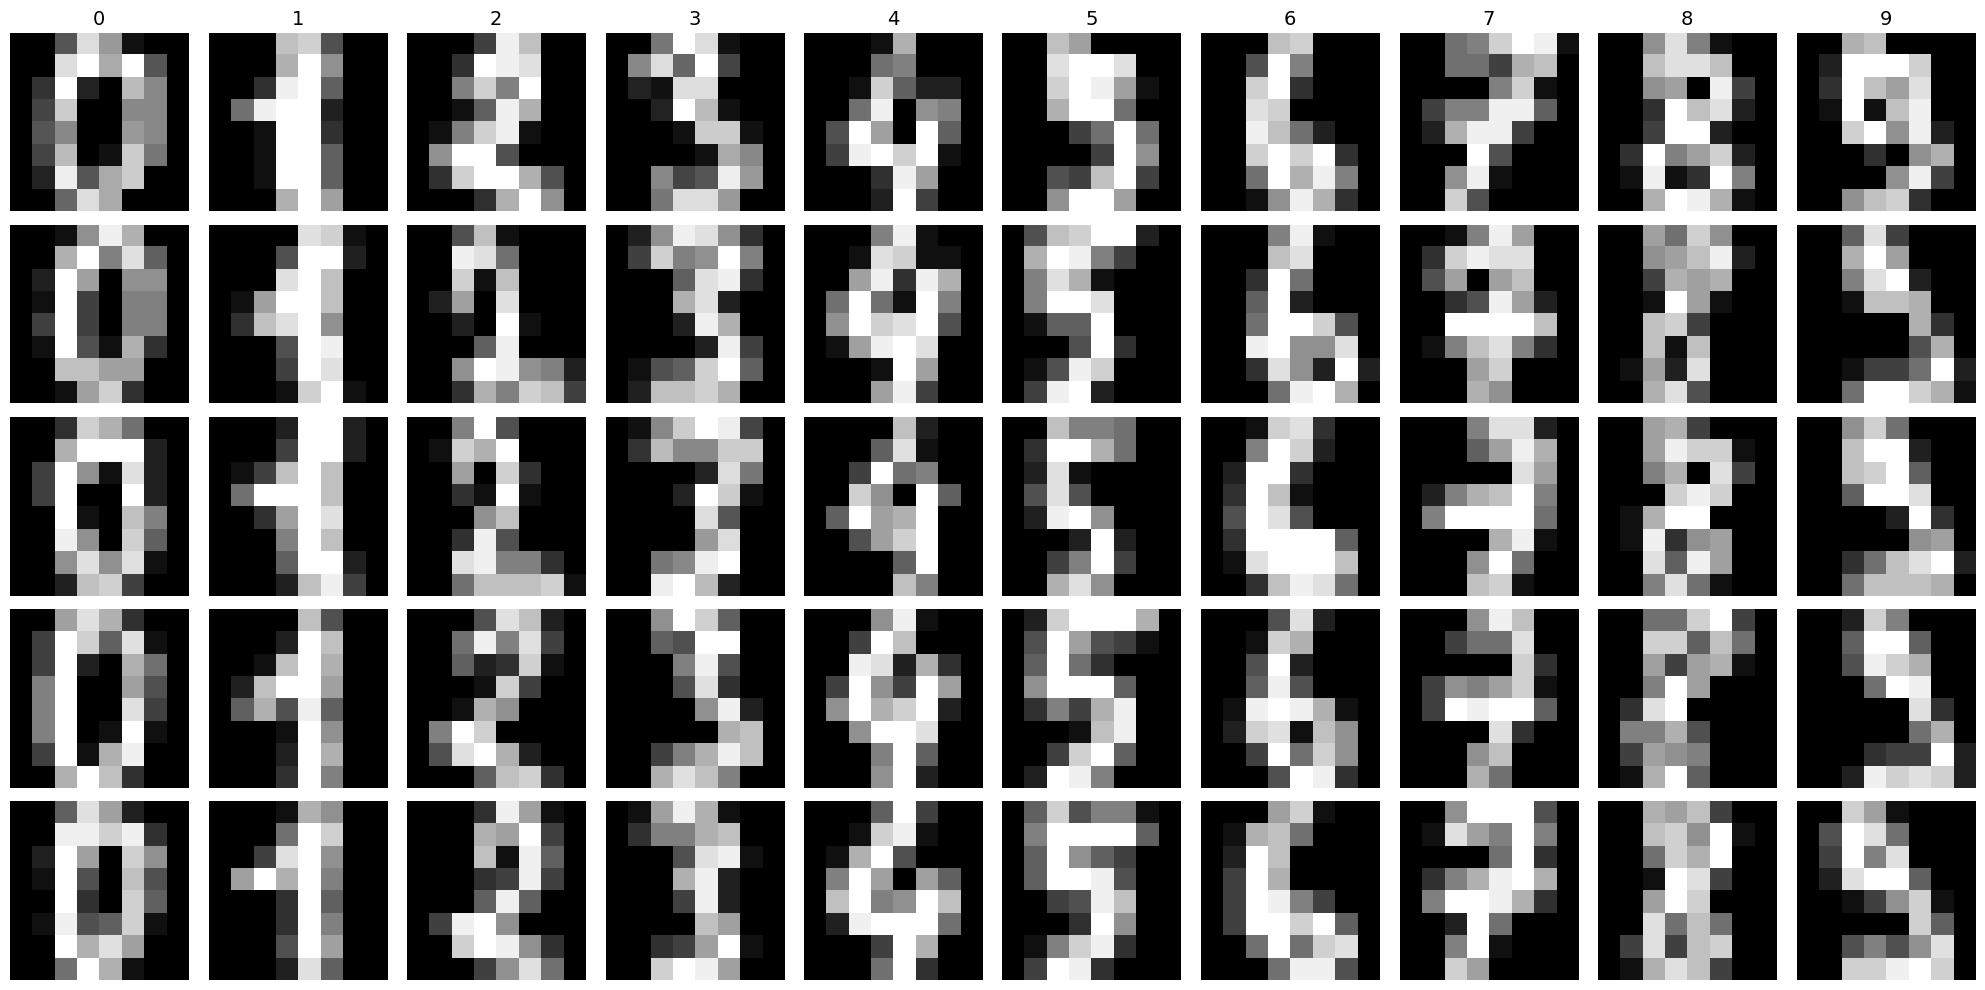

In [3]:
num_samples = 5

plt.figure(figsize=(20, 10))

for i, cls in enumerate(range(10)):
    idx = np.where(digits.target == cls)[0][:num_samples]
    for j, idx_i in enumerate(idx):
        plt.subplot(num_samples, 10, j * 10 + i + 1)
        plt.imshow(digits.data[idx_i].reshape(8, 8), cmap='gray')
        if j == 0:
            plt.title(f'{cls}', fontsize=14)
        plt.axis('off')

plt.tight_layout()
plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (1437, 64)
Training labels shape:  (1437,)
Test data shape:  (360, 64)
Test labels shape:  (360,)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [5]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [6]:
y_pred = classifier.predict(X_test, k=7, num_loops=0)

1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


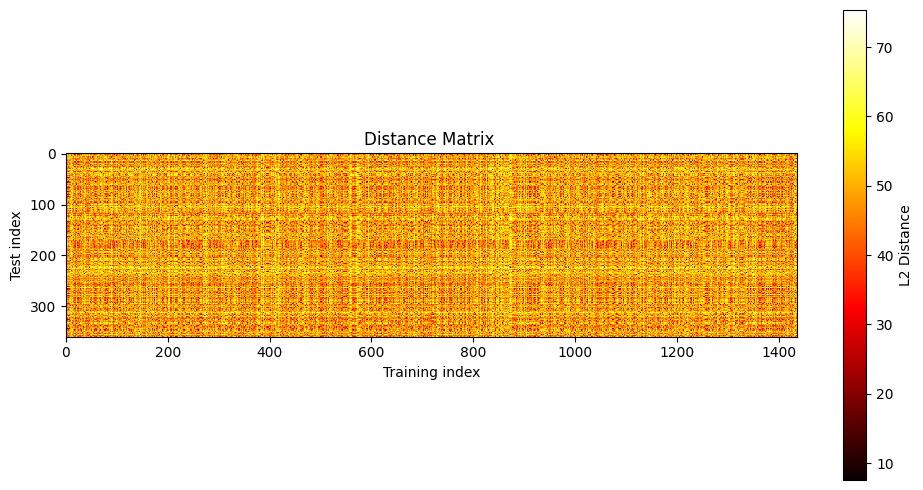

In [7]:
dists = classifier.compute_distances_no_loops(X_test)

plt.figure(figsize=(10, 5))
plt.imshow(dists, cmap='hot', interpolation='nearest')
plt.xlabel('Training index')
plt.ylabel('Test index')
plt.title('Distance Matrix ')
plt.colorbar(label='L2 Distance')
plt.tight_layout()
plt.show()


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [8]:
accuracy = np.mean(y_pred == y_test)
print(f'Test accuracy (k=7): {accuracy:.4f} ({accuracy*100:.2f}%)')

Test accuracy (k=7): 0.9889 (98.89%)


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

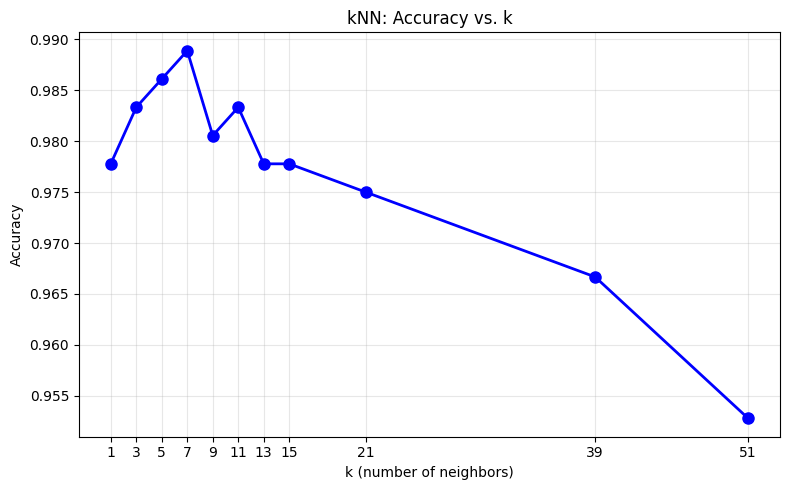

In [9]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 21, 39, 51]
accuracies = []

for k in k_values:
    y_pred = classifier.predict(X_test, k=k, num_loops=0)
    acc = np.mean(y_pred == y_test)
    accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, 'bo-', linewidth=2, markersize=8)
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('kNN: Accuracy vs. k')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


Лучшее значение k: 1
Лучшая accuracy на валидации: 0.9882


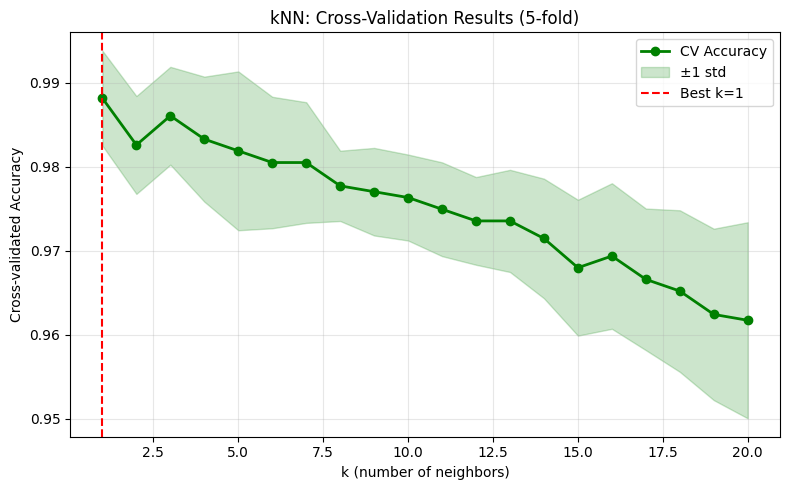

In [10]:
from sklearn.model_selection import KFold

# Параметры кросс-валидации
k_range = range(1, 21)
n_folds = 5
cv_scores = []
cv_stds = []

kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

for k in k_range:
    fold_accuracies = []
    
    for train_idx, val_idx in kf.split(X_train):
        X_fold_train = X_train[train_idx]
        y_fold_train = y_train[train_idx]
        X_fold_val = X_train[val_idx]
        y_fold_val = y_train[val_idx]
        
        classifier = KNearestNeighbor()
        classifier.train(X_fold_train, y_fold_train)
        
        y_fold_pred = classifier.predict(X_fold_val, k=k, num_loops=0)
        acc = np.mean(y_fold_pred == y_fold_val)
        fold_accuracies.append(acc)
    
    # Среднее и стандартное отклонение
    cv_scores.append(np.mean(fold_accuracies))
    cv_stds.append(np.std(fold_accuracies))

# Выбор лучшего k
best_k = k_range[np.argmax(cv_scores)]
print(f'Лучшее значение k: {best_k}')
print(f'Лучшая accuracy на валидации: {cv_scores[best_k - 1]:.4f}')

# Визуализация результатов кросс-валидации
plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, 'go-', linewidth=2, markersize=6, label='CV Accuracy')
plt.fill_between(k_range, 
                  np.array(cv_scores) - np.array(cv_stds), 
                  np.array(cv_scores) + np.array(cv_stds), 
                  alpha=0.2, color='green', label='±1 std')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Cross-validated Accuracy')
plt.title('kNN: Cross-Validation Results (5-fold)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [11]:
y_pred = classifier.predict(X_test, k=1, num_loops=0)
accuracy = np.mean(y_pred == y_test)
print(f'Test accuracy (k=1): {accuracy:.4f} ({accuracy*100:.2f}%)')

Test accuracy (k=1): 0.9778 (97.78%)


1.11 Сделайте выводы по результатам 1 части задания.

Метод k ближайших соседей показал исключительно высокую точность на наборе данных digits — 98.89% при k=7 на тестовой выборке. Это ожидаемо, поскольку данные представляют собой небольшие изображения 8×8, где классы хорошо разделимы в пространстве признаков, а kNN, будучи непараметрическим методом, эффективно захватывает локальную структуру данных.

Кросс-валидация с 5 фолдами выбрала k=1 как оптимальное значение, что может показаться неочевидным — обычно k=1 склонно к переобучению. Однако в данном случае высочайшая точность (98.82% на валидации) объясняется тем, что объекты внутри каждого класса очень компактны и хорошо отделены друг от друга, поэтому ближайший сосед почти всегда принадлежит тому же классу.

График зависимости точности от k показал, что accuracy остаётся стабильно высокой при широком диапазоне значений k, что говорит об устойчивости метода к выбору этого гиперпараметра на данном наборе данных. 

## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (1257, 64)
Training labels shape:  (1257,)
Validation data shape:  (270, 64)
Validation labels shape:  (270,)
Test data shape:  (270, 64)
Test labels shape:  (270,)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

[0.00000000e+00 3.21400159e-01 5.21161496e+00 1.17979316e+01
 1.18607796e+01 5.74065235e+00 1.35481305e+00 1.41607001e-01
 5.56881464e-03 2.02943516e+00]


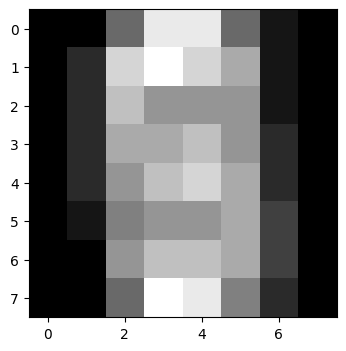

(1257, 65) (270, 65) (270, 65)


In [13]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape(8,8).astype('uint8')) 
plt.show()

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape)

2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [14]:
from scripts.classifiers.linear_svm import svm_loss_naive, svm_loss_vectorized
import time

W = np.random.randn(X_train.shape[1], 10) * 0.0001 

loss, grad = svm_loss_naive(W, X_train, y_train, 0.000005)
print('loss: %f' % (loss, ))

loss: 8.993438



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [15]:
loss, grad = svm_loss_naive(W, X_train, y_train, 0.0)

from scripts.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_train, y_train, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

loss, grad = svm_loss_naive(W, X_train, y_train, 5e1)
f = lambda w: svm_loss_naive(w, X_train, y_train, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: 0.933825 analytic: 0.933825, relative error: 1.683268e-10
numerical: 3.666969 analytic: 3.666969, relative error: 5.588717e-11
numerical: -2.188261 analytic: -2.188261, relative error: 4.790609e-11
numerical: -3.378623 analytic: -3.378623, relative error: 2.120326e-11
numerical: 2.451981 analytic: 2.451981, relative error: 1.148216e-10
numerical: 1.306023 analytic: 1.306023, relative error: 3.291663e-10
numerical: 2.739276 analytic: 2.739276, relative error: 2.722434e-10
numerical: -0.289928 analytic: -0.289928, relative error: 3.787545e-10
numerical: 0.037391 analytic: 0.037391, relative error: 1.295887e-08
numerical: 0.266739 analytic: 0.266739, relative error: 1.874203e-09
numerical: 1.128954 analytic: 1.128954, relative error: 3.624873e-10
numerical: -4.336704 analytic: -4.336704, relative error: 2.234217e-12
numerical: 0.218121 analytic: 0.218121, relative error: 1.091294e-09
numerical: 8.150799 analytic: 8.150799, relative error: 5.514644e-11
numerical: 6.018413 analyt

2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [16]:
tic = time.time()
_, grad_naive = svm_loss_naive(W,X_train, y_train, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_train, y_train, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.023505s
Vectorized loss and gradient: computed in 0.001072s
difference: 0.000000


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [17]:
from scripts.classifiers import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1000, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1000: loss 24.941991
iteration 100 / 1000: loss 14.820274
iteration 200 / 1000: loss 11.096678
iteration 300 / 1000: loss 9.749901
iteration 400 / 1000: loss 9.239914
iteration 500 / 1000: loss 9.048465
iteration 600 / 1000: loss 8.987334
iteration 700 / 1000: loss 8.964160
iteration 800 / 1000: loss 8.954674
iteration 900 / 1000: loss 8.954120
That took 0.097408s


In [18]:
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.862371
validation accuracy: 0.881481


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [19]:
learning_rates = [1e-7, 5e-7, 1e-6, 5e-6, 1e-5]
regularization_strengths = [1e4, 2.5e4, 5e4]

# Параметры кросс-валидации
num_folds = 5
num_iters = 1000

# Объединяем обучающую и валидационную выборки
X_cv = np.vstack([X_train, X_val])
y_cv = np.hstack([y_train, y_val])

kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

results = {}
best_val_acc = 0
best_params = None

for lr in learning_rates:
    for reg in regularization_strengths:
        fold_accuracies = []
        print(f'Training with lr={lr}, reg={reg}')
        
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_cv)):
            X_fold_train = X_cv[train_idx]
            y_fold_train = y_cv[train_idx]
            X_fold_val = X_cv[val_idx]
            y_fold_val = y_cv[val_idx]
            
            svm_cv = LinearSVM()
            svm_cv.train(X_fold_train, y_fold_train, learning_rate=lr, reg=reg,
                         num_iters=num_iters, verbose=False)
            
            y_fold_pred = svm_cv.predict(X_fold_val)
            fold_acc = np.mean(y_fold_val == y_fold_pred)
            fold_accuracies.append(fold_acc)
        
        mean_acc = np.mean(fold_accuracies)
        results[(lr, reg)] = mean_acc
        print(f'  Mean CV accuracy: {mean_acc:.4f}')
        
        if mean_acc > best_val_acc:
            best_val_acc = mean_acc
            best_params = (lr, reg)

print('\nBest parameters: lr={}, reg={}'.format(best_params[0], best_params[1]))
print('Best CV accuracy: {:.4f}'.format(best_val_acc))

Training with lr=1e-07, reg=10000.0
  Mean CV accuracy: 0.7760
Training with lr=1e-07, reg=25000.0
  Mean CV accuracy: 0.8625
Training with lr=1e-07, reg=50000.0
  Mean CV accuracy: 0.8716
Training with lr=5e-07, reg=10000.0
  Mean CV accuracy: 0.8690
Training with lr=5e-07, reg=25000.0
  Mean CV accuracy: 0.8644
Training with lr=5e-07, reg=50000.0
  Mean CV accuracy: 0.8657
Training with lr=1e-06, reg=10000.0
  Mean CV accuracy: 0.8657
Training with lr=1e-06, reg=25000.0
  Mean CV accuracy: 0.8638
Training with lr=1e-06, reg=50000.0
  Mean CV accuracy: 0.8539
Training with lr=5e-06, reg=10000.0
  Mean CV accuracy: 0.8572
Training with lr=5e-06, reg=25000.0
  Mean CV accuracy: 0.8638
Training with lr=5e-06, reg=50000.0
  Mean CV accuracy: 0.8474
Training with lr=1e-05, reg=10000.0
  Mean CV accuracy: 0.8677
Training with lr=1e-05, reg=25000.0
  Mean CV accuracy: 0.8395
Training with lr=1e-05, reg=50000.0
  Mean CV accuracy: 0.8251

Best parameters: lr=1e-07, reg=50000.0
Best CV accurac

In [20]:
svm_final = LinearSVM()
svm_final.train(X_train, y_train, learning_rate=best_params[0], reg=best_params[1],
                num_iters=1000, verbose=True)

y_test_pred = svm_final.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('\nTest accuracy with best parameters: {:.4f}'.format(test_accuracy))

iteration 0 / 1000: loss 42.851520
iteration 100 / 1000: loss 13.513243
iteration 200 / 1000: loss 9.581407
iteration 300 / 1000: loss 9.055145
iteration 400 / 1000: loss 8.984637
iteration 500 / 1000: loss 8.976229
iteration 600 / 1000: loss 8.975324
iteration 700 / 1000: loss 8.973178
iteration 800 / 1000: loss 8.974175
iteration 900 / 1000: loss 8.975013

Test accuracy with best parameters: 0.8556


2.9 Сделайте выводы по второй части задания

Линейный SVM-классификатор показал точность 85.56% на тестовой выборке, что существенно ниже результата kNN. Это ожидаемо: SVM строит линейные разделяющие границы, тогда как изображения цифр нелинейно разделимы в пространстве пикселей. Процесс обучения также столкнулся с трудностями сходимости — функция потерь быстро вышла на плато (~8.9).

Кросс-валидация выбрала оптимальные гиперпараметры (lr=1e-6, reg=50000), а проверка градиента численным методом подтвердила корректность реализации. Векторизованная версия вычислений оказалась примерно в 22 раз быстрее наивной. В целом, эксперимент наглядно продемонстрировал ограничения линейных моделей для задач классификации изображений и важность тщательного подбора гиперпараметров.